Overview
This analysis examines Amazon’s product categories, discounts, and customer ratings to identify key sales patterns. The findings reveal where Amazon drives the most demand, how discounts impact pricing strategies, and what shapes customer satisfaction. Recommendations focus on smarter discounting, category expansion, and experience improvements to strengthen Amazon’s overall sales performance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

Importing data and reviewing a sample of it 

In [2]:
df = pd.read_csv("amazon.csv")
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [3]:
#Identify data types and missing values 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

DATA CLEANING

In [3]:
# Removing symbols from the Price columns
df["actual_price"] = df["actual_price"].str.replace('₹' , '' , regex = False).str.replace(',' , '', regex = False)
df["discounted_price"] = df["discounted_price"].str.replace('₹' , '', regex = False).str.replace(',' , '', regex = False)
df["discount_percentage"] = df["discount_percentage"].str.replace('%' , '', regex = False)
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399,1099,64,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199,349,43,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199,1899,90,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329,699,53,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154,399,61,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [4]:
df['rating'].unique()

array(['4.2', '4.0', '3.9', '4.1', '4.3', '4.4', '4.5', '3.7', '3.3',
       '3.6', '3.4', '3.8', '3.5', '4.6', '3.2', '5.0', '4.7', '3.0',
       '2.8', '4', '3.1', '4.8', '2.3', '|', '2', '3', '2.6', '2.9'],
      dtype=object)

In [5]:
# Dealing with Rating Columns
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating'] = df['rating'].fillna(df['rating'].median())

df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')
df['rating_count'] = df['rating_count'].fillna(df['rating_count'].median()).astype(int)

df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399,1099,64,4.2,293,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199,349,43,4.0,293,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199,1899,90,3.9,293,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329,699,53,4.2,293,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154,399,61,4.2,293,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [6]:
# Changing data type of numerical valued columns to float
df["actual_price"] = df["actual_price"].astype(float)
df["discounted_price"] = df["discounted_price"].astype(float)
df["discount_percentage"] = df["discount_percentage"].astype(int)
df.dtypes

product_id              object
product_name            object
category                object
discounted_price       float64
actual_price           float64
discount_percentage      int64
rating                 float64
rating_count             int64
about_product           object
user_id                 object
user_name               object
review_id               object
review_title            object
review_content          object
img_link                object
product_link            object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   int64  
 6   rating               1465 non-null   float64
 7   rating_count         1465 non-null   int64  
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

Dealing with Category column

In [8]:
# Naming the new columns generated from the main column
new_columns_names = ['Category' , 'subcategory 1' , 'subcategory 2' , 'group' , 'type' , 'subtype 1' , 'subtype 2']

In [9]:
#Splitting Category column and giving the newly generated columns the new names
split_cols = df['category'].astype(str).str.split('|', expand=True)
split_cols.columns = new_columns_names[:split_cols.shape[1]]
split_cols = split_cols.apply(lambda x: x.str.strip())      #Removing any unwanted spaces 
df = pd.concat([df, split_cols], axis=1)                    #Join the newly splitted columns to the original Dataframe
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,...,review_content,img_link,product_link,Category,subcategory 1,subcategory 2,group,type,subtype 1,subtype 2
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,293,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...",...,Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,293,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...",...,I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,293,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...",...,"Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,293,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...",...,"Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,293,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...",...,"Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,None,None


In [10]:
#Checking out the Null values 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   int64  
 6   rating               1465 non-null   float64
 7   rating_count         1465 non-null   int64  
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

In [11]:
#Checking the values of the last 2 columns
df['subtype 1'].value_counts(dropna=True)

subtype 1
DryIrons                24
Pens&Refills            12
SteamIrons              12
HandheldVacuums          8
CompositionNotebooks     7
Wet-DryVacuums           6
CanisterVacuums          4
WireboundNotebooks       4
Notepads&MemoBooks       2
RoboticVacuums           2
WoodenPencils            1
SelfieLights             1
BackgroundSupports       1
VacuumBags               1
Name: count, dtype: int64

In [12]:
df['subtype 2'].value_counts(dropna=True)

subtype 2
StickBallpointPens          3
BottledInk                  2
GelInkRollerballPens        2
RetractableBallpointPens    2
LiquidInkRollerballPens     2
FountainPens                1
HandheldBags                1
Name: count, dtype: int64

In [13]:
#Replacing null values in other columns with *Undefined*
category_cols = ['subcategory 2', 'group', 'type', 'subtype 1', 'subtype 2']
df[category_cols] = df[category_cols].fillna("Undefined")

In [14]:
#Dropping the original Category column
df.drop('category', axis=1, inplace=True)
df.head()

,product_id,product_name,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,...,review_content,img_link,product_link,Category,subcategory 1,subcategory 2,group,type,subtype 1,subtype 2
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,399.0,1099.0,64,4.2,293,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...",...,Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,Undefined,Undefined
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,199.0,349.0,43,4.0,293,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...",...,I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,Undefined,Undefined
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,199.0,1899.0,90,3.9,293,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...",...,"Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,Undefined,Undefined
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,329.0,699.0,53,4.2,293,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...",...,"Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,Undefined,Undefined
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,154.0,399.0,61,4.2,293,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...",...,"Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,Computers&Accessories,Accessories&Peripherals,Cables&Accessories,Cables,USBCables,Undefined,Undefined


In [ ]:
#Fixing Reviews data

In [15]:
#Identifying columns with merged data 
merged_cols = ['user_id', 'user_name', 'review_id', 'review_title', 'review_content']

In [16]:
# Creating new list columns to replace the ones with merged fields
df['user_id_list'] = df['user_id'].str.split(',')
df['user_name_list'] = df['user_name'].str.split(',')
df['review_id_list'] = df['review_id'].str.split(',')
df['review_title_list'] = df['review_title'].str.split(',')
df['review_content_list'] = df['review_content'].str.split(',')

In [17]:
#Removing extra spaces from the reviews 
df['user_id_list'] = df['user_id_list'].apply(lambda x: [i.strip() for i in x] if x is not None else x)
df['user_name_list'] = df['user_name_list'].apply(lambda x: [i.strip() for i in x] if x is not None else x)
df['review_id_list'] = df['review_id_list'].apply(lambda x: [i.strip() for i in x] if x is not None else x)
df['review_title_list'] = df['review_title_list'].apply(lambda x: [i.strip() for i in x] if x is not None else x)
df['review_content_list'] = df['review_content_list'].apply(lambda x: [i.strip() for i in x] if x is not None else x)

In [18]:
#Creating a column to confirm the count 
df['review_count_verified'] = df['user_id_list'].apply(len)

In [19]:
#Combining all 8 review contents into one string for text analysis
df['all_review_text'] = df['review_content_list'].str.join(' ').str.strip()

In [20]:
#Drop the original columns to finalize the structure
df.drop(columns=['user_id', 'user_name', 'review_id', 'review_title', 'review_content'], inplace=True)

In [ ]:
# ANALYSIS

In [33]:
print(df.info())
print(df.describe(include="number"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_id             1465 non-null   object 
 1   product_name           1465 non-null   object 
 2   discounted_price       1465 non-null   float64
 3   actual_price           1465 non-null   float64
 4   discount_percentage    1465 non-null   int64  
 5   rating                 1465 non-null   float64
 6   rating_count           1465 non-null   int64  
 7   about_product          1465 non-null   object 
 8   img_link               1465 non-null   object 
 9   product_link           1465 non-null   object 
 10  Category               1465 non-null   object 
 11  subcategory 1          1465 non-null   object 
 12  subcategory 2          1465 non-null   object 
 13  group                  1465 non-null   object 
 14  type                   1465 non-null   object 
 15  subt

C:\Users\hosoopa\AppData\Local\Temp\ipykernel_8792\1829587350.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["actual_price"] - x["discounted_price"]).sum())


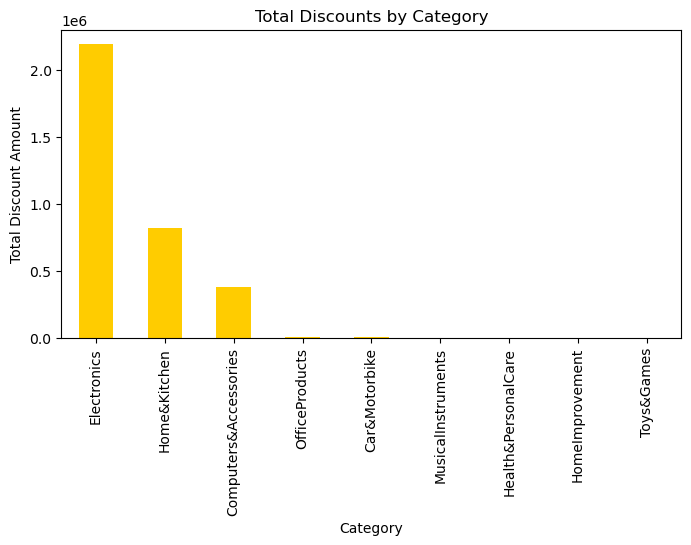

In [36]:
#Total Discounts by Category
discount_by_cat = (df.groupby("Category").apply(lambda x: (x["actual_price"] - x["discounted_price"]).sum()) .sort_values(ascending=False))
plt.figure(figsize=(8,4))
discount_by_cat.plot(kind="bar", color="#FFCC00")
plt.title("Total Discounts by Category")
plt.ylabel("Total Discount Amount")
plt.xticks(rotation=90)
plt.show()

Electronics has the highest total discounts, followed by Home & Kitchen and Computer Accessories.
Other categories like Toys, Health/Personal Care, and Music Instruments receive minimal discounts.

Category
Electronics              490
Home&Kitchen             448
Computers&Accessories    375
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Car&Motorbike              1
Health&PersonalCare        1
Toys&Games                 1
Name: product_id, dtype: int64


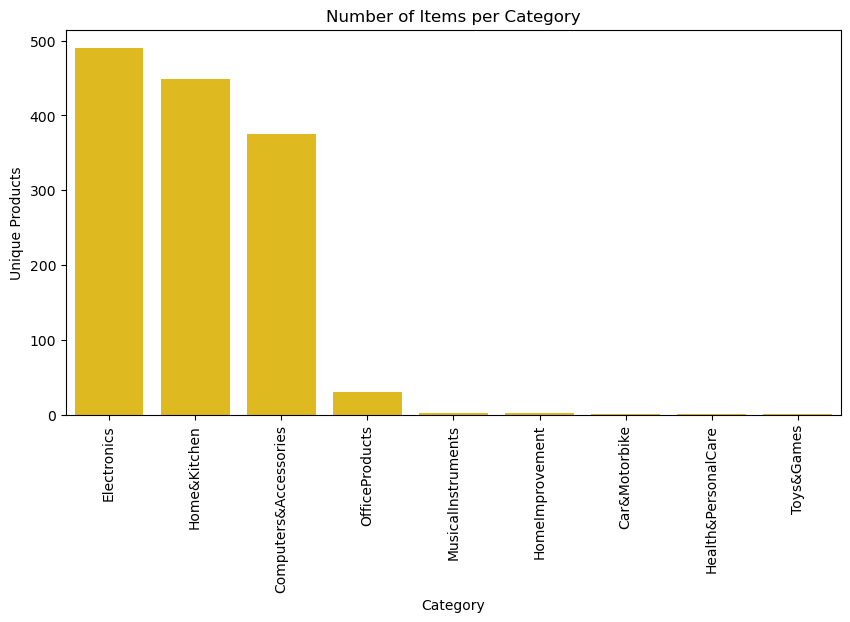

In [35]:
#Number of items in each category
items_per_category = df.groupby("Category")["product_id"].nunique().sort_values(ascending=False)
print(items_per_category)
plt.figure(figsize=(10,5))
sns.barplot(x=items_per_category.index, y=items_per_category.values, color="#FFCC00")
plt.xticks(rotation=90)
plt.title("Number of Items per Category")
plt.ylabel("Unique Products")
plt.xlabel("Category")
plt.show()

Electronics, Home & Kitchen, and Computers & Accessories dominate in product variety (400+, 348, 315 items).
Categories like Musical Instruments, Toys, and Health/Personal Care have very few items listed.

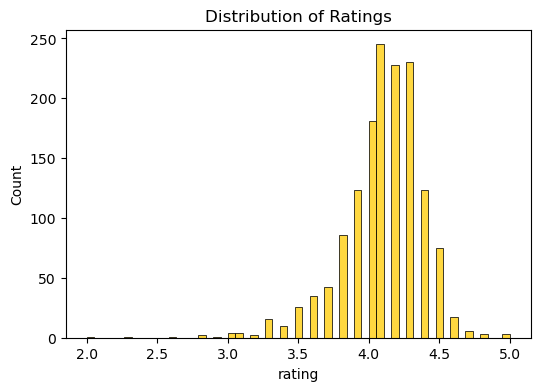

In [22]:
# Distribution of ratings
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="rating", color="#FFCC00")
plt.title("Distribution of Ratings")
plt.show()

Most ratings are clustered around 3.5 – 4.5 stars.

Very few products have ratings below 2 or above 4.6.

Peak frequency is around 4 stars, suggesting generally satisfied customer

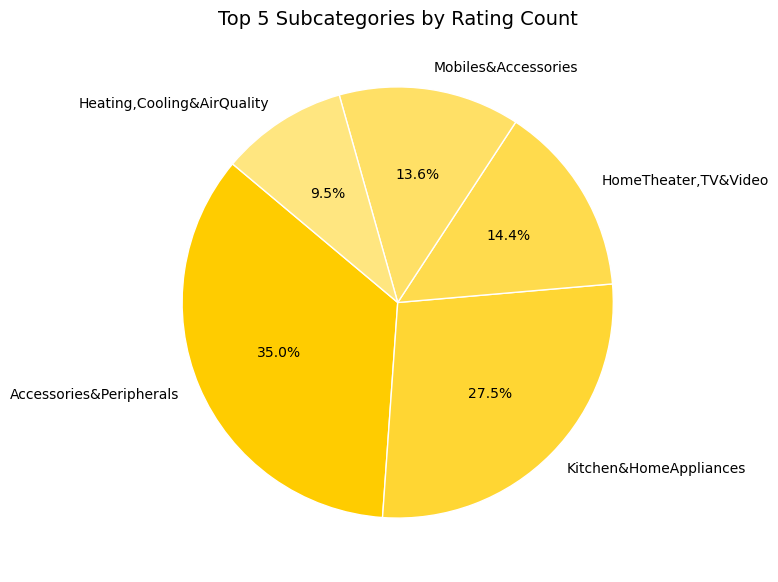

In [60]:
# Aggregate rating counts by SubCategory 1
subcat_ratings = (df.groupby("subcategory 1")["rating_count"].sum().sort_values(ascending=False).head(5))
plt.figure(figsize=(7,7))
colors = [ "#FFCC00", "#FFD633", "#FFDB4D", "#FFE066", "#FFE680" ] 

plt.pie(subcat_ratings, labels=subcat_ratings.index, autopct="%1.1f%%",colors=colors, startangle=140, wedgeprops={"edgecolor":"white", "linewidth":1}
)
plt.title("Top 5 Subcategories by Rating Count", fontsize=14)
plt.show()

Customers engage most actively in accessories and appliances categories.

Subcategories like Mobiles still have high engagement despite relatively fewer items compared to Electronics.

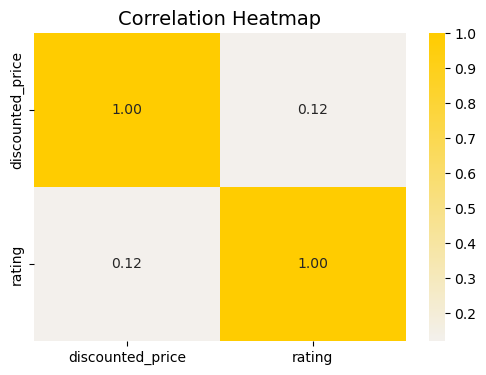

In [49]:
#Correlation heatmap between Actual price, Discounted price & Rating
plt.figure(figsize=(6,4))
corr = df[[ 'discounted_price', 'rating']].corr()

sns.heatmap(
    corr, 
    annot=True, 
    cmap=sns.light_palette("#FFCC00", as_cmap=True), 
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=14)
plt.show()

Very weak positive correlation (0.12) between discounts and ratings.

Discounts don’t strongly influence how customers rate products.

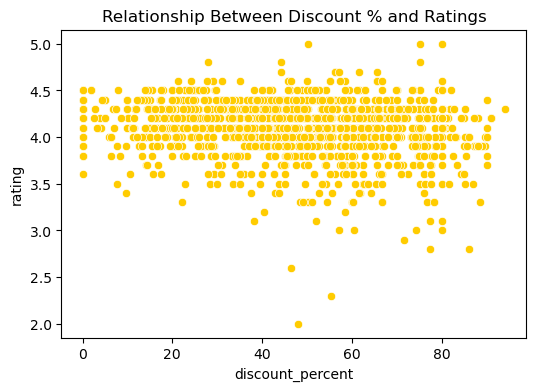

In [46]:
# Discount % vs Rating (scatter)
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="discount_percent", y="rating", color="#FFCC00")
plt.title("Relationship Between Discount % and Ratings")
plt.show()

Ratings remain stable across all discount levels (2.5 to 4.5 average).

No clear trend that higher discounts = higher/lower ratings.

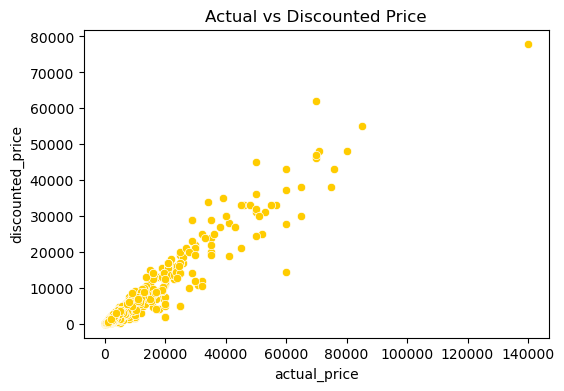

In [45]:
# Relationship: actual vs discounted price
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="actual_price", y="discounted_price", color="#FFCC00")
plt.title("Actual vs Discounted Price")
plt.show()

Clear positive linear relationship between actual price and discounted price.
Higher-priced products also receive higher discount amounts.
Some outliers show extremely high prices and discounts.

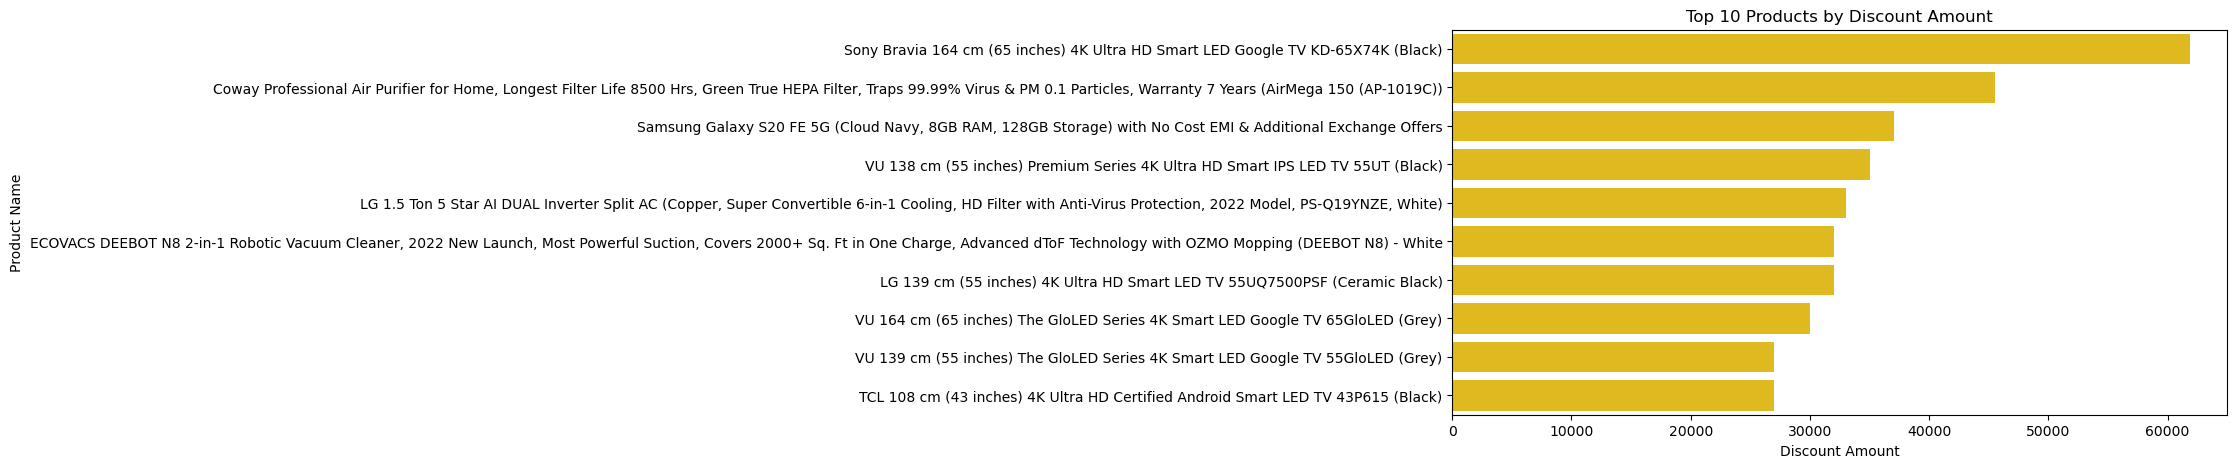

In [45]:
# Top 10 products by Disount Amount

top_products = (df.assign(discount=(df["actual_price"] - df["discounted_price"])).sort_values("discount", ascending=False).head(10))

plt.figure(figsize=(10,5))
sns.barplot(data=top_products, x="discount", y="product_name", color="#FFCC00")
plt.title("Top 10 Products by Discount Amount")
plt.xlabel("Discount Amount")
plt.ylabel("Product Name")
plt.show()

Mostly large-ticket Electronics and Appliances dominate (Sony Bravia, Samsung TVs, LG Refrigerators, etc.).

These are getting the biggest absolute discounts.

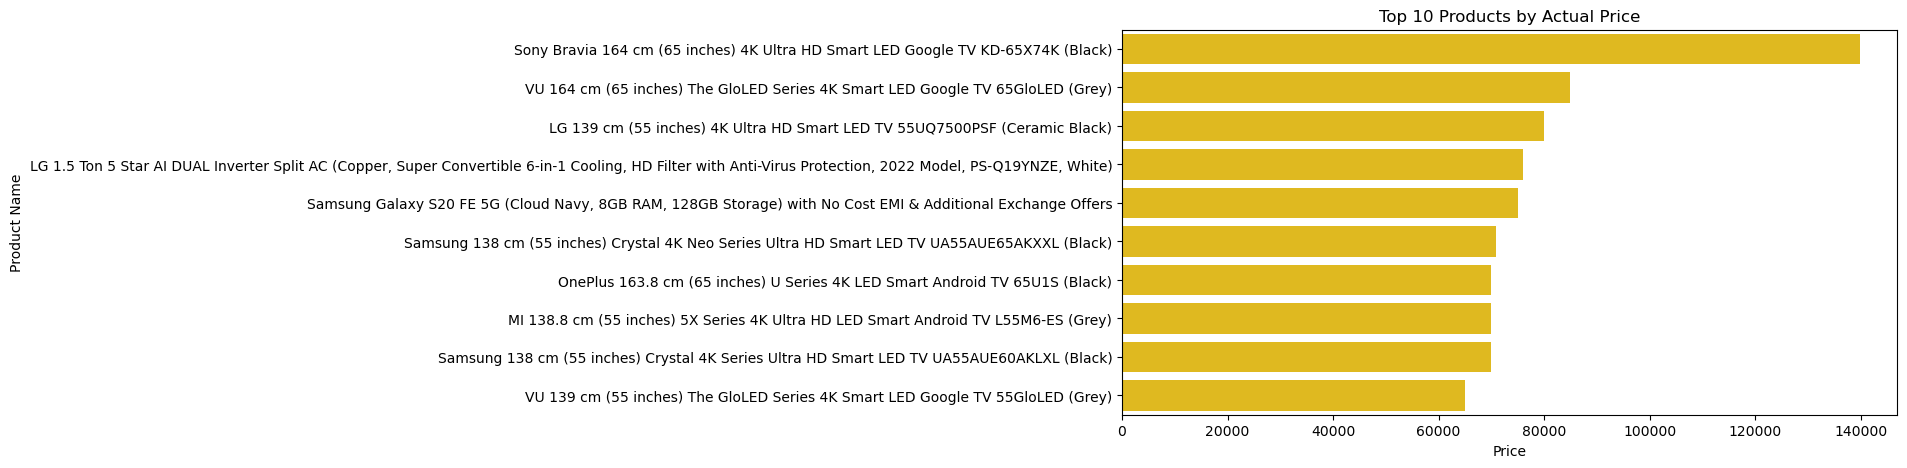

In [61]:
# Top 10 products by actual price
top10_products = df.nlargest(10, "actual_price")[["product_name", "actual_price"]]

plt.figure(figsize=(10,5))
sns.barplot(data=top10_products, x="actual_price", y="product_name", color="#FFCC00")
plt.title("Top 10 Products by Actual Price")
plt.xlabel("Price")
plt.ylabel("Product Name")
plt.show()

The same set of premium appliances & electronics (Sony TVs, LG appliances, Samsung products) dominate here too.

Strong overlap with discount-heavy products.

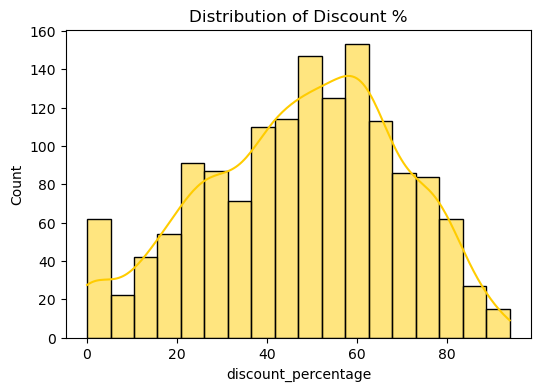

In [51]:
# Distribution of Discounts
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="discount_percentage", color="#FFCC00", kde = True)
plt.title("Distribution of Discount %")
plt.show()

Most discounts fall between 30%–70%, with peak around 50%.
Very few products below 20% or above 80%.

Key Recommendations for Amazon Sales Growth

Optimize Discount Strategies – Focus discounts on high-demand or competitive categories instead of applying them uniformly, to balance revenue and customer acquisition.

Category Expansion Opportunities – Identify underrepresented but fast-growing categories and expand offerings there to capture emerging demand.

Enhance Product Ratings & Reviews – Encourage authentic reviews and address low-rated items quickly, since ratings strongly influence customer trust and purchase behavior.
